<a href="https://colab.research.google.com/github/PranjalKabra/Fairness-Movie-Recommender/blob/main/Notebook_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import zipfile
import math
from sklearn.metrics import accuracy_score, r2_score

In [3]:
print(tf.__version__)

2.20.0


## Unzip the data

In [4]:
zip_path = '/content/dataset_movie.zip'
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
  if(zipfile.is_zipfile(zip_path)):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)
      ratings_file = os.path.join(extract_path, "u.data")
      user_attribute_file = os.path.join(extract_path, "u.user")


In [5]:
ratings_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(ratings_file, sep='\t', names=ratings_cols)
ratings = ratings.drop('unix_timestamp', axis=1)
# ratings

In [8]:
user_attributes_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv(user_attribute_file, sep='|', names=user_attributes_cols)
# users

Allot 0 to Male and 1 To female

In [12]:
ratings['count'] = ratings.groupby('user_id')['movie_id'].transform('count')
ratings = ratings[ratings['count'] >= 300]
users['gender'] = users['gender'].map(lambda x: 1 if x == 'F' else 0)
users = users.drop(['age', 'occupation', 'zip_code'], axis=1)

# len(ratings['user_id'].unique())

In [13]:
df = pd.merge(ratings, users, on='user_id', how='left')
df.head()
# len(df['user_id'].unique())

,user_id,movie_id,rating,count,gender
0,303,785,3,484,0
1,194,274,2,305,0
2,234,1184,2,480,0
3,308,1,4,397,0
4,181,1081,1,435,0


## Encoding Data for Embeddings

In [15]:
user_ids = df["user_id"].unique().tolist()
movie_ids = df["movie_id"].unique().tolist()

user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)} # For decoding later
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)} # For decoding later

df["users"] = df["user_id"].map(user2user_encoded)
df["movies"] = df["movie_id"].map(movie2movie_encoded)

In [17]:
num_users = len(user_ids)
num_movies = len(movie_ids)
min_rating = min(df['rating'])
max_rating = max(df['rating'])

df['rating'] = df['rating'].values.astype(np.float32)

print(f'Number of users: {num_users}')
print(f'Number of movies: {num_movies}')
print(f'Min rating: {min_rating}')
print(f'Max rating: {max_rating}')
print(df.head())

Number of users: 54
Number of movies: 1597
Min rating: 1
Max rating: 5
   user_id  movie_id  rating  count  gender  users  movies
0      303       785     3.0    484       0      0       0
1      194       274     2.0    305       0      1       1
2      234      1184     2.0    480       0      2       2
3      308         1     4.0    397       0      3       3
4      181      1081     1.0    435       0      4       4


## Train & Test Split

In [18]:
df = df.sample(frac=1, random_state=42)
# xtract input
x = df[["users", "movies"]].values

# xtract targets
y_rating = df["rating"].values
# y_rating = df["rating"].values.map(lambda x: (x - min_rating) / (max_rating - min_rating)).values
y_gender = df["gender"].values

# splitting
train_indices = int(0.9 * df.shape[0])
x_train, x_val = x[:train_indices], x[train_indices:]

In [19]:
# build the massive 7-lists together answer key for Multi-Task Learning!
y_train = [
    y_rating[:train_indices],    # Target 1: Actual Rating
    y_gender[:train_indices],  # Target 2: Gender Biased mlp
    y_gender[:train_indices],  # Target 3: Gender Biased gmf
    y_gender[:train_indices],  # Target 4 :Fair mlp (Goal: Guess WRONG)
    y_gender[:train_indices],   # Target 5: Fair gmf (Goal: Guess WRONG)
    np.zeros(train_indices),    # Target 6: Zeros ub
    np.zeros(train_indices)    # Target 7: Zeros ud
]

y_val = [
    y_rating[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    np.zeros(df.shape[0]-train_indices),
    np.zeros(df.shape[0]-train_indices)
]

print('x_train shape : ', x_train.shape)
print('x_val shape   : ', x_val.shape)
print(y_train[0][0:10])

x_train shape :  (18944, 2)
x_val shape   :  (2105, 2)
[5. 3. 3. 5. 3. 4. 2. 3. 4. 5.]


## FairRec NeuCF model

In [20]:
EMBEDDING_SIZE = 50

class RecommenderSys(keras.Model):
    def __init__(self, num_users, num_movies, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = EMBEDDING_SIZE

        # BIAS-AWARE USER VECTORS (u_b_mlp)
        self.user_embedding_biased_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-AWARE USER VECTORS (u_b_gmf)
        self.user_embedding_biased_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_d_mlp)
        self.user_embedding_fair_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_d_gmf)
        self.user_embedding_fair_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings mlp
        self.movie_embedding_mlp = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings gmf
        self.movie_embedding_gmf = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # mlp for combining user embeddings for mlp and movie embeddings for mlp
        self.mlp = keras.models.Sequential([
            layers.Dense(4*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(2*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(EMBEDDING_SIZE),
        ])

        # NN(no hidden layers) to combine mlp and gmf outputs
        self.neuCF = layers.Dense(1)

        # NNs(no hdden layers)  (To predict Gender)
        self.att_predictor_mlp = layers.Dense(1)
        self.att_predictor_gmf = layers.Dense(1)

        # NNs(no hdden layers)  (To discriminate Gender)
        self.att_discriminator_mlp = layers.Dense(1)
        self.att_discriminator_gmf = layers.Dense(1)

    def call(self, inputs):
        # get the user embeddings
        u_b_mlp = self.user_embedding_biased_mlp(inputs[:, 0])
        u_b_gmf = self.user_embedding_biased_gmf(inputs[:, 0])
        u_f_mlp = self.user_embedding_fair_mlp(inputs[:, 0])
        u_f_gmf = self.user_embedding_fair_gmf(inputs[:, 0])

        # get themovie embeddings
        m_mlp = self.movie_embedding_mlp(inputs[:, 1])
        m_gmf = self.movie_embedding_gmf(inputs[:, 1])

        # combining fair and biased user embeddings(u = ub + uf)
        u_mlp = tf.add(u_b_mlp, u_f_mlp)
        u_gmf = tf.add(u_b_gmf, u_f_gmf)

        # make the prediction layer for gmf and mlp
        gmf_layer = tf.multiply(u_gmf, m_gmf)
        mlp_layer = self.mlp(tf.concat([u_mlp, m_mlp], axis = 1))

        # final predicted rating
        predicted_rating = self.neuCF(tf.concat([gmf_layer, mlp_layer], 1))

        # gender predictor
        z_b_mlp = self.att_predictor_mlp(u_b_mlp) # z cap
        z_b_gmf = self.att_predictor_gmf(u_b_gmf)  # z tilda

        # gender discrimator
        z_f_mlp = self.att_discriminator_gmf(u_f_gmf)
        z_f_gmf = self.att_discriminator_mlp(u_f_mlp)

        # compute orthogonality loss which should be minimized btwn u_b and u_f
        ortho_loss_mlp = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_mlp, u_f_mlp])
        ortho_loss_gmf = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_gmf, u_f_gmf])

        # the sigmoid activation forces the rating to between 0 and 1
        return [
            predicted_rating,
            tf.nn.sigmoid(z_b_mlp),
            tf.nn.sigmoid(z_b_gmf),
            tf.nn.sigmoid(z_f_mlp),
            tf.nn.sigmoid(z_f_gmf),
            ortho_loss_mlp,
            ortho_loss_gmf
        ]

## Loss func

In [21]:
def neg_binary_crossentropy(y_true, y_pred):
    return -1.0 * keras.losses.binary_crossentropy(y_true, y_pred)

def root_mean_squared_error(y_true, y_pred):
    return keras.backend.sqrt(keras.backend.mean(keras.backend.square(y_pred - y_true)))

In [23]:
model = RecommenderSys(num_users, num_movies)
model.compile(
    loss=[root_mean_squared_error, tf.keras.losses.BinaryCrossentropy(), tf.keras.losses.BinaryCrossentropy(), neg_binary_crossentropy, neg_binary_crossentropy, tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanSquaredError()],
    loss_weights=[1,0.5,0.5,0.5,0.5,0.5,0],
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
)

## Train

In [24]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=20,
    verbose=1,
    validation_data=(x_val, y_val),
)

Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - binary_crossentropy_loss: 0.2837 - loss: -1.2296 - mean_squared_error_loss: 0.0191 - neg_binary_crossentropy_loss: -1.8474 - root_mean_squared_error_loss: 1.1025 - val_binary_crossentropy_loss: 0.0461 - val_loss: -6.1374 - val_mean_squared_error_loss: 0.0151 - val_neg_binary_crossentropy_loss: -4.6895 - val_root_mean_squared_error_loss: 0.9523
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_crossentropy_loss: 0.0201 - loss: -16.4281 - mean_squared_error_loss: 0.0136 - neg_binary_crossentropy_loss: -13.2136 - root_mean_squared_error_loss: 0.9268 - val_binary_crossentropy_loss: 0.0087 - val_loss: -29.6016 - val_mean_squared_error_loss: 0.0130 - val_neg_binary_crossentropy_loss: -24.8447 - val_root_mean_squared_error_loss: 0.9296
Epoch 3/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_crossentropy_loss: 0.0055 - loss: -48.0412 - mean_squared_error_loss: 0.0126 - neg_binary_crossentropy_loss: -42.1909 - root_mean_squ

In [25]:
model.evaluate(x_val, y_val)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - binary_crossentropy_loss: 4.3229e-05 - loss: -2311.6846 - mean_squared_error_loss: 0.0205 - neg_binary_crossentropy_loss: -2292.0518 - root_mean_squared_error_loss: 1.0713


[-2311.6845703125,
 1.0712878704071045,
 4.3229389120824635e-05,
 4.3229389120824635e-05,
 -2292.0517578125,
 -2292.0517578125,
 0.020520905032753944,
 0.020520905032753944]

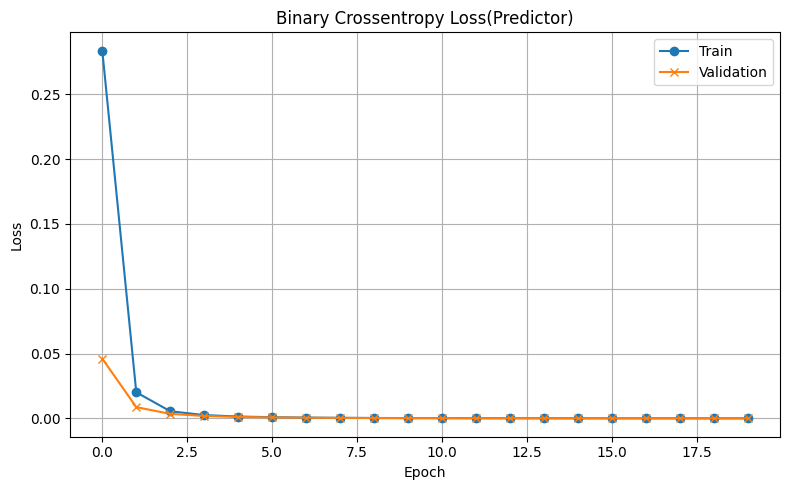

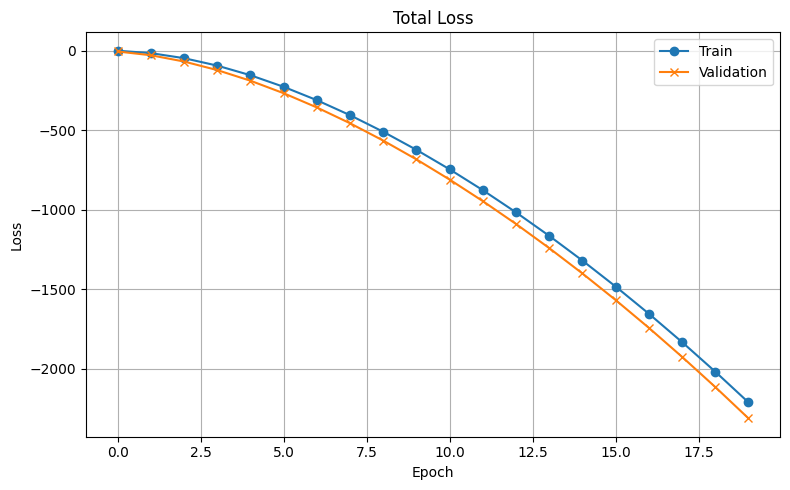

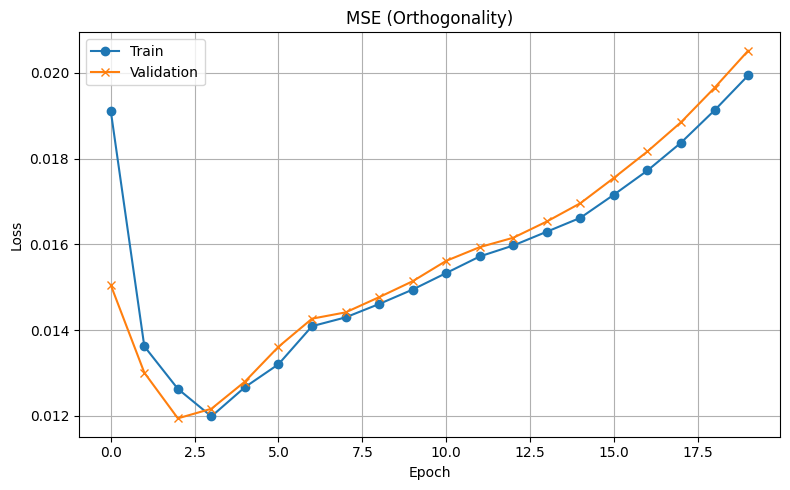

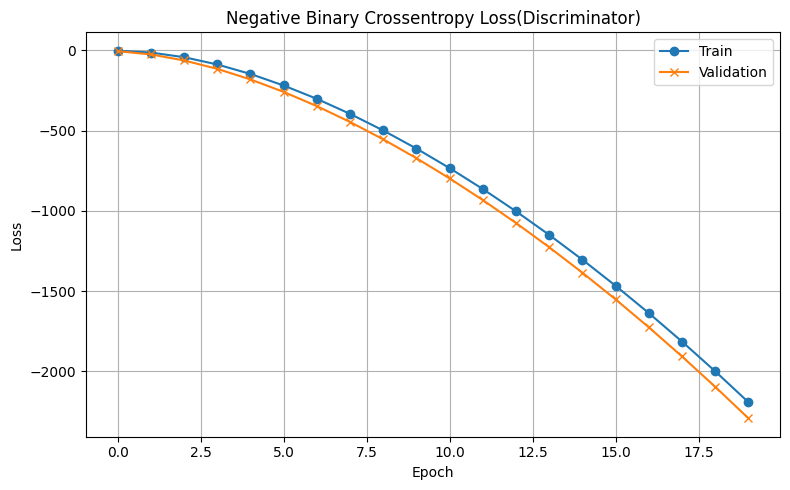

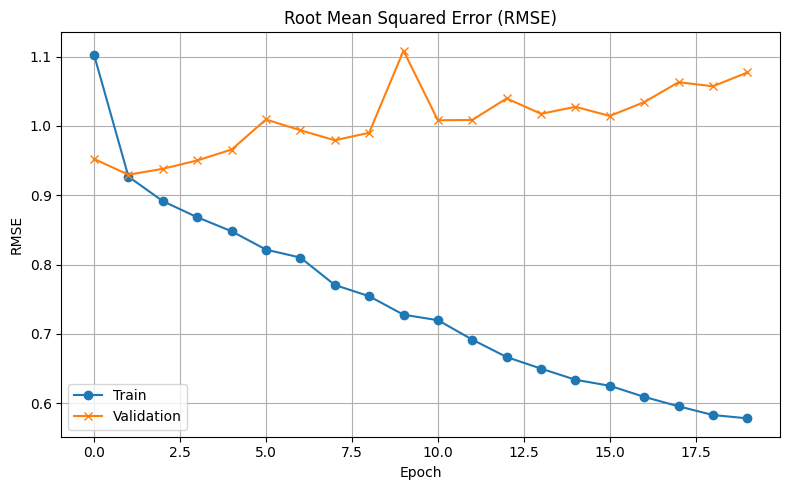

In [26]:
def plot_metrics(history, key, title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[key], marker='o', label='Train')
    plt.plot(history.history["val_" + key], marker='x', label='Validation')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the plot function for each metric
plot_metrics(history, "binary_crossentropy_loss", "Binary Crossentropy Loss(Predictor)", "Loss")
plot_metrics(history, "loss", "Total Loss", "Loss")
plot_metrics(history, "mean_squared_error_loss", "MSE (Orthogonality)", "Loss")
plot_metrics(history, "neg_binary_crossentropy_loss", "Negative Binary Crossentropy Loss(Discriminator)", "Loss")
plot_metrics(history, "root_mean_squared_error_loss", "Root Mean Squared Error (RMSE)", "RMSE")

# Unified User embeddings

In [27]:
# UNIFIED USER EMBEDDINGS

ub_mlp_w = np.array(model.user_embedding_biased_mlp.get_weights())
ub_gmf_w = np.array(model.user_embedding_biased_gmf.get_weights())
# print(np.shape(model.user_embedding_biased_mlp.get_weights()))
uf_mlp_w = np.array(model.user_embedding_fair_mlp.get_weights())
uf_gmf_w = np.array(model.user_embedding_fair_gmf.get_weights())

unified_user_embedding = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

output = unified_user_embedding(x_train[:,0])
# print(np.shape(unified_user_embedding.get_weights()))
w_mlp = np.add(ub_mlp_w, uf_mlp_w)
w_gmf = np.add(ub_gmf_w, uf_gmf_w)
w = np.add(w_mlp,w_gmf)
unified_user_embedding.set_weights(w)

# print(w.shape)

In [28]:
# TESTING

movies_embedding = model.movie_embedding_mlp
uv = model.user_embedding_biased_mlp(x_train[:,0])
mv = movies_embedding(x_train[:,1])
scores = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1])

mse = tf.keras.losses.MeanSquaredError()
mse(y_train[0], scores).numpy()

np.float32(12.54537)

In [32]:
movie_df = pd.read_csv('/content/extracted_data/u.item', sep='|', header=None, encoding='latin-1')
movie_df = movie_df[[0, 1]]
movie_df.columns = ['movie_id', 'title']
movie_df.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [36]:
# TOP 10 FAIRNESS AWARE MOVIE RECOMMENDATIONS FOR A RANDOM USER USING BIAS-FREE EMBEDDINGS

user_id = df.user_id.sample(1).iloc[0] # Keep this in another cell else random user will change each time the cell runs
# user_id = 234
movies_watched_by_user = df[df.user_id == user_id]
movies_not_watched = movie_df[~movie_df['movie_id'].isin(movies_watched_by_user.movie_id.values)]['movie_id']
movies_not_watched = list(
    set(movies_not_watched).intersection(set(movie2movie_encoded.keys()))
)
movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]

user_encoder = user2user_encoded.get(user_id)
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched)
)

# print('len : ',len(user_movie_array))
uv = unified_user_embedding(user_movie_array[:,0])
mv = movies_embedding(user_movie_array[:,1])
ratings = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1]).numpy()
# print(ratings)

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices
]

print("Showing recommendations for user: {}".format(user_id))
print("====" * 9)
print("Movies with high ratings from user")
print("----" * 8)
top_movies_user = (
    movies_watched_by_user.sort_values(by="rating", ascending=False)
    .head(5)
    .movie_id.values
)
movie_df_rows = movie_df[movie_df["movie_id"].isin(top_movies_user)]
for row in movie_df_rows.itertuples():
    print(row.title)

print("----" * 8)
print("Top 10 movie recommendations")
print("----" * 8)
recommended_movies = movie_df[movie_df["movie_id"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(row.title)

Showing recommendations for user: 758
Movies with high ratings from user
--------------------------------
Welcome to the Dollhouse (1995)
Men in Black (1997)
Deconstructing Harry (1997)
M (1931)
Hard Eight (1996)
--------------------------------
Top 10 movie recommendations
--------------------------------
Priest (1994)
Kull the Conqueror (1997)
Transformers: The Movie, The (1986)
Fatal Instinct (1993)
Stalingrad (1993)
Christmas Carol, A (1938)
Blood Beach (1981)
Kull the Conqueror (1997)
Diva (1981)
Strawberry and Chocolate (Fresa y chocolate) (1993)


In [37]:
# Evaluation

uv = unified_user_embedding(x_val[:,0])
mv = movies_embedding(x_val[:,1])
ratings = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1]).numpy()
ratings = tf.nn.sigmoid(ratings)
# print(len(y_val[0]), len(ratings))
# print(y_val[0])
# print(ratings)

rmse = tf.keras.metrics.RootMeanSquaredError()
rmse.update_state(y_val[0],ratings)
print('RMSE : ',rmse.result().numpy())
r2 = r2_score(y_val[0], np.array(ratings)) # Tells whether Model explains the variance in the dataset (1 -> perfect, 0 -> same as predicting mean for all, negative -> worse)
print('Coefficient of Determination : ',r2)

RMSE :  3.0929828
Coefficient of Determination :  -6.310284614562988


## Testing Fairness

In [38]:

discriminator = keras.Sequential([
    layers.Input(shape=(EMBEDDING_SIZE,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

gender_labels = []
for key in userencoded2user:
    gender_labels.append(df.loc[df["users"] == key, "gender"].values[0])
gender_labels = np.array(gender_labels).astype(int)

# len(gender_labels)
biased_embeddings = np.array(ub_mlp_w[0])
fair_embeddings = np.array(uf_mlp_w[0])
# print(fair_embeddings.shape, len(gender_labels))
history = discriminator.fit(biased_embeddings, gender_labels, epochs=10, batch_size=32)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 890ms/step - accuracy: 0.6852 - loss: 0.6324
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7963 - loss: 0.5877
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8889 - loss: 0.5456
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9074 - loss: 0.5056
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9074 - loss: 0.4691
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9259 - loss: 0.4349
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9444 - loss: 0.4031
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9815 - loss: 0.3738
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9815 - loss: 0.3459
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9815 - loss: 0.3202


In [39]:
gender_predictions = discriminator.predict(fair_embeddings)
score = 0
for x in gender_predictions:
    score += abs(x-0.5)

score /= len(gender_predictions)
print(score)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
[0.36534977]


In [40]:
yr = model.predict(x_val)[0]
yr.shape

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


(2105, 1)

In [42]:
from collections import defaultdict

In [44]:
e_g_y_j_all = defaultdict(list)
e_neg_g_y_j_all = defaultdict(list)
e_g_r_j_all = defaultdict(list)
e_neg_g_r_j_all = defaultdict(list)

# print("---",np.count_nonzero(y_val[1]==1))
# print(x_val.shape)
for i in range(len(x_val)):
    if(y_val[1][i] == 1): #female
        e_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_g_r_j_all[x_val[i][1]].append(y_val[0][i])
    if(y_val[1][i] == 0): #male
        e_neg_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_neg_g_r_j_all[x_val[i][1]].append(y_val[0][i])

In [45]:
e_g_y_j = {}
e_neg_g_y_j = {}
e_g_r_j = {}
e_neg_g_r_j = {}
for k in e_g_y_j_all:
  e_g_y_j[k] = np.nanmean(e_g_y_j_all[k])
for k in e_g_r_j_all:
  e_g_r_j[k] = np.nanmean(e_g_r_j_all[k])
for k in e_neg_g_y_j_all:
  e_neg_g_y_j[k] = np.nanmean(e_neg_g_y_j_all[k])
for k in e_neg_g_r_j_all:
  e_neg_g_r_j[k] = np.nanmean(e_neg_g_r_j_all[k])
# print(e_g_y_j)

In [46]:
movies = set(x_val[:,1])
l = len(movies)
# print(l)

def safe_val(d, key):
    val = d.get(key, 0)
    return 0 if val is None or np.isnan(val) else val

val_score, abs_score, over_est, under_est = 0.0, 0.0, 0.0, 0.0

for movie in movies:
    eg_y = safe_val(e_g_y_j, movie)
    eg_r = safe_val(e_g_r_j, movie)
    eng_y = safe_val(e_neg_g_y_j, movie)
    eng_r = safe_val(e_neg_g_r_j, movie)

    val_score += np.abs((eg_y - eg_r) - (eng_y - eng_r))
    abs_score += np.abs(np.abs(eg_y - eg_r) - np.abs(eng_y - eng_r))
    over_est += np.abs(np.maximum(0, eg_y - eg_r) - np.maximum(0, eng_y - eng_r))
    under_est += np.abs(np.maximum(0, eg_r - eg_y) - np.maximum(0, eng_r - eng_y))

val_score /= l
abs_score /= l
over_est /= l
under_est /= l

print(val_score, abs_score, over_est, under_est)

0.87402195 0.7683153412989433 0.5701082361981306 0.30391381026366954
